# Classification Basics

This notebook provides a comprehensive introduction to classification in machine learning, covering fundamental concepts, popular algorithms, and practical implementation.

## Import Required Libraries

In [1]:
# Import essential libraries for classification tasks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For data preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# For handling imbalanced datasets
from imblearn.over_sampling import SMOTE

# Set up visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.2)

## Understanding Classification

Classification is a supervised learning task where the model learns to categorize data points into predefined classes based on input features.

### Key Characteristics of Classification:
- **Supervised Learning**: Requires labeled training data
- **Discrete Output**: Predicts categorical class labels
- **Decision Boundaries**: Models learn to create boundaries between classes
- **Applications**: Spam detection, disease diagnosis, sentiment analysis, image recognition

### Classification vs. Regression

| Classification | Regression |
|----------------|------------|
| Predicts discrete class labels | Predicts continuous values |
| Output: Categories (e.g., Yes/No, Dog/Cat/Bird) | Output: Numbers (e.g., price, temperature) |
| Evaluation: Accuracy, precision, recall | Evaluation: MAE, MSE, RMSE |
| Example: Is this email spam? | Example: What will be tomorrow's temperature? |

## Types of Classification Algorithms

Let's explore the most common classification algorithms, their characteristics, and use cases.

### 1. Logistic Regression

Despite its name, logistic regression is a classification algorithm, not a regression algorithm. It estimates the probability that a given input belongs to a certain class.

**Key characteristics:**
- Simple and interpretable
- Works well with linearly separable data
- Provides probability scores
- Computationally efficient

Logistic Regression Accuracy: 1.0000


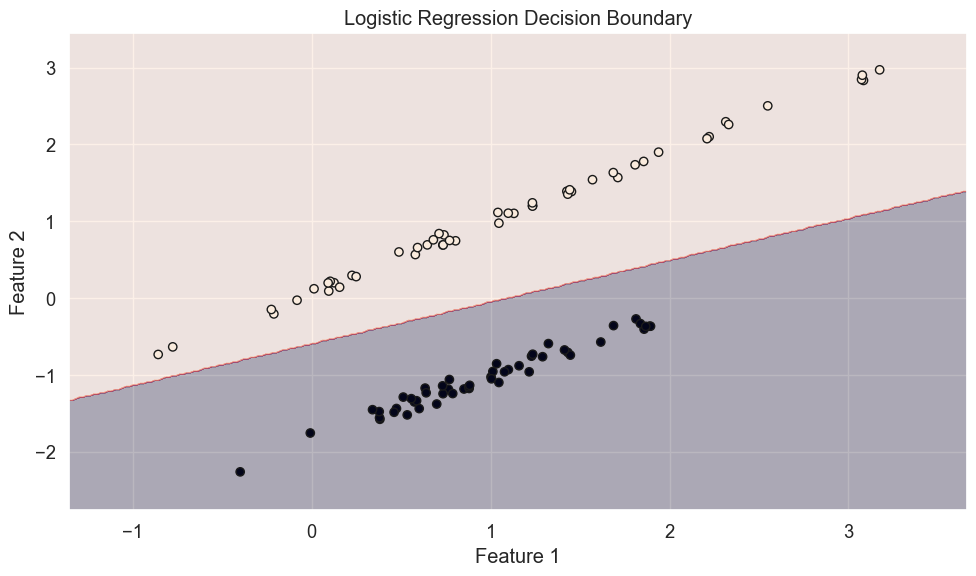

In [2]:
# Simple example of Logistic Regression
from sklearn.datasets import make_classification

# Generate a synthetic dataset
X, y = make_classification(
    n_samples=100, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Visualize the decision boundary
def plot_decision_boundary(X, y, model, title="Decision Boundary"):
    plt.figure(figsize=(10, 6))
    
    # Determine the plotting boundaries
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Create a mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict the function value for the whole grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.tight_layout()
    plt.show()

# Plot the decision boundary
plot_decision_boundary(X, y, log_reg, "Logistic Regression Decision Boundary")

### 2. Decision Trees

Decision trees create a model that predicts the target class by learning simple decision rules inferred from the data.

**Key characteristics:**
- Intuitive and easy to interpret
- Can handle both numerical and categorical data
- No need for feature scaling
- Prone to overfitting (especially with deep trees)

Decision Tree Accuracy: 1.0000


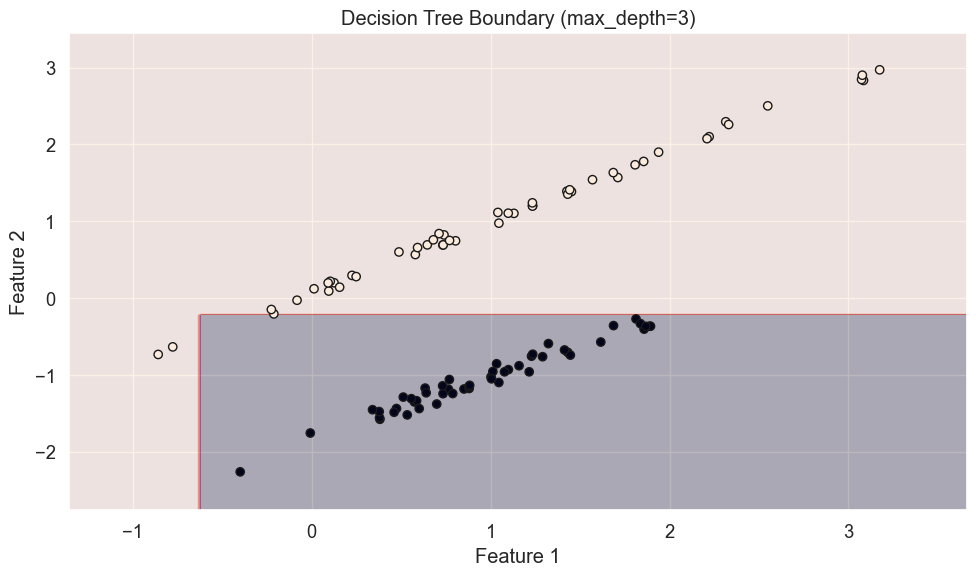

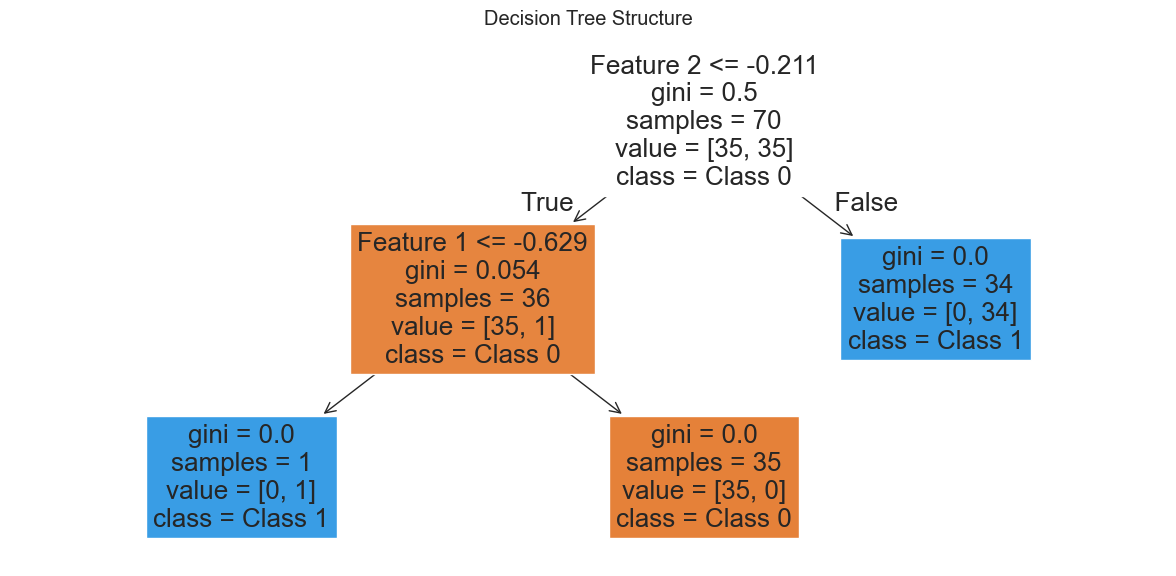

In [3]:
# Decision Tree example
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

# Visualize the decision boundary
plot_decision_boundary(X, y, dt, "Decision Tree Boundary (max_depth=3)")

# Visualize the actual tree structure
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 6))
plot_tree(dt, filled=True, feature_names=[f"Feature {i+1}" for i in range(2)], class_names=["Class 0", "Class 1"])
plt.title("Decision Tree Structure")
plt.tight_layout()
plt.show()

### 3. k-Nearest Neighbors (KNN)

KNN classifies a data point based on the majority class of its k nearest neighbors in the feature space.

**Key characteristics:**
- Simple and intuitive
- Non-parametric (no assumptions about data distribution)
- Computationally intensive for large datasets
- Sensitive to feature scaling

KNN Accuracy: 1.0000


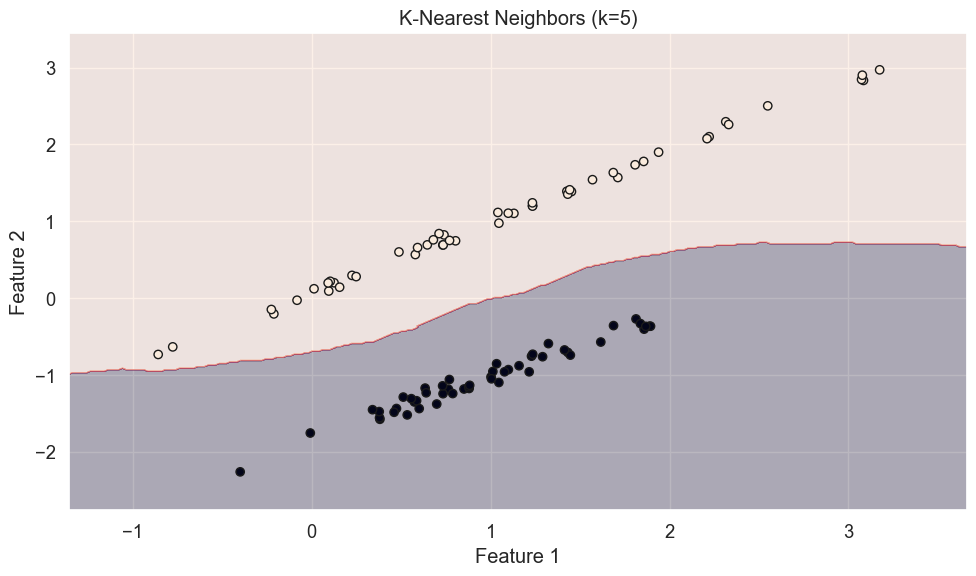

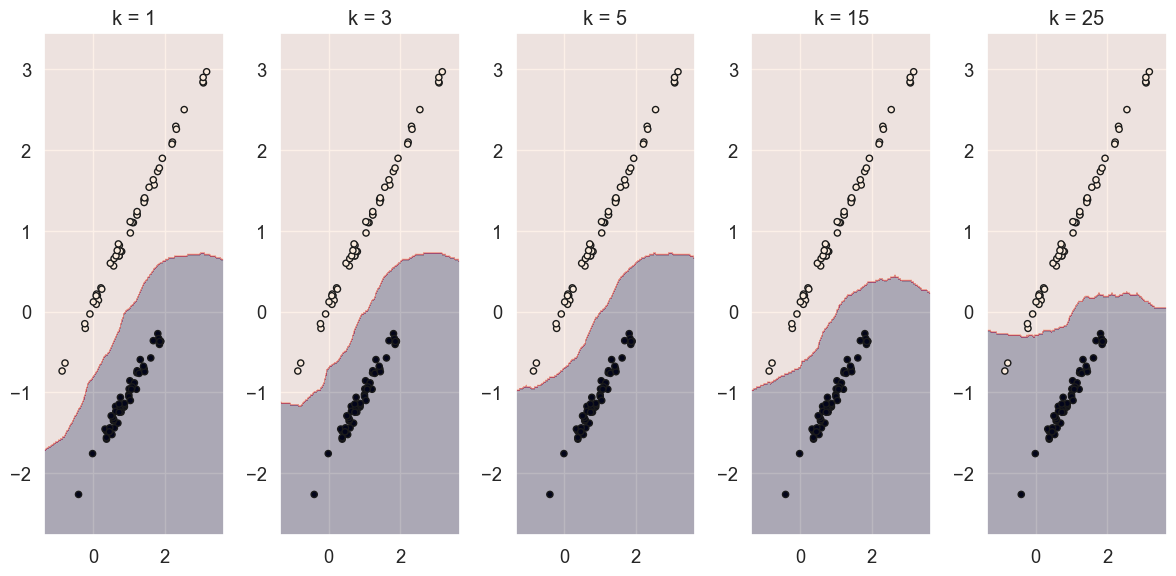

In [4]:
# KNN example
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

# Visualize the decision boundary
plot_decision_boundary(X, y, knn, "K-Nearest Neighbors (k=5)")

# Show impact of different k values
plt.figure(figsize=(12, 6))
k_values = [1, 3, 5, 15, 25]
for i, k in enumerate(k_values):
    plt.subplot(1, 5, i+1)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Create mesh grid for decision boundary
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title(f"k = {k}")
    
plt.tight_layout()
plt.show()

### 4. Naive Bayes

Naive Bayes classifiers are based on applying Bayes' theorem with strong (naive) independence assumptions between features.

**Key characteristics:**
- Fast and efficient
- Works well with high-dimensional data
- Requires less training data
- Assumes feature independence (which is often not true in real-world data)

Naive Bayes Accuracy: 0.9667


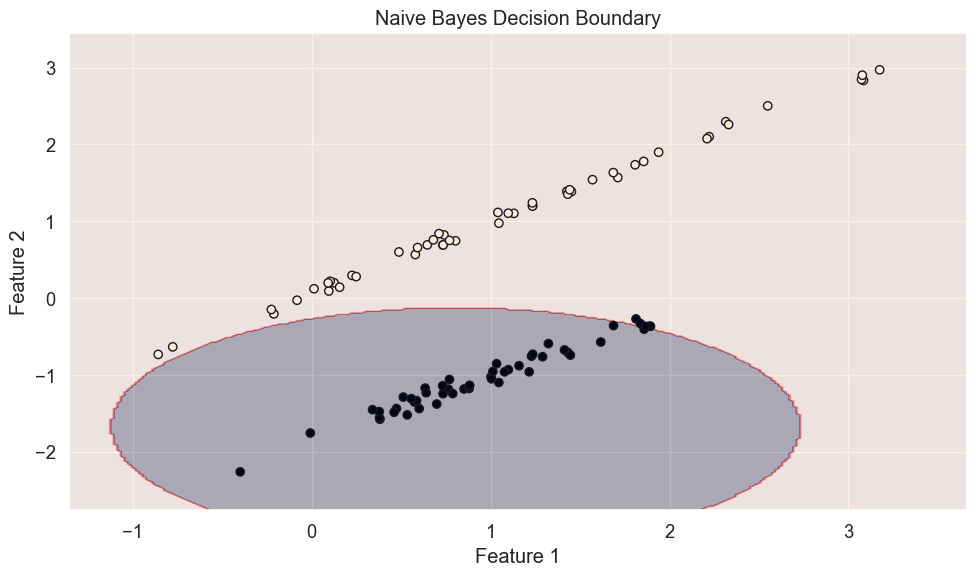

In [5]:
# Naive Bayes example
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")

# Visualize the decision boundary
plot_decision_boundary(X, y, nb, "Naive Bayes Decision Boundary")

### 5. Support Vector Machines (SVM)

SVM finds the hyperplane that best separates different classes with the maximum margin.

**Key characteristics:**
- Effective in high-dimensional spaces
- Memory efficient as it uses only a subset of training points (support vectors)
- Versatile through different kernel functions
- Can be sensitive to feature scaling

Linear SVM Accuracy: 1.0000


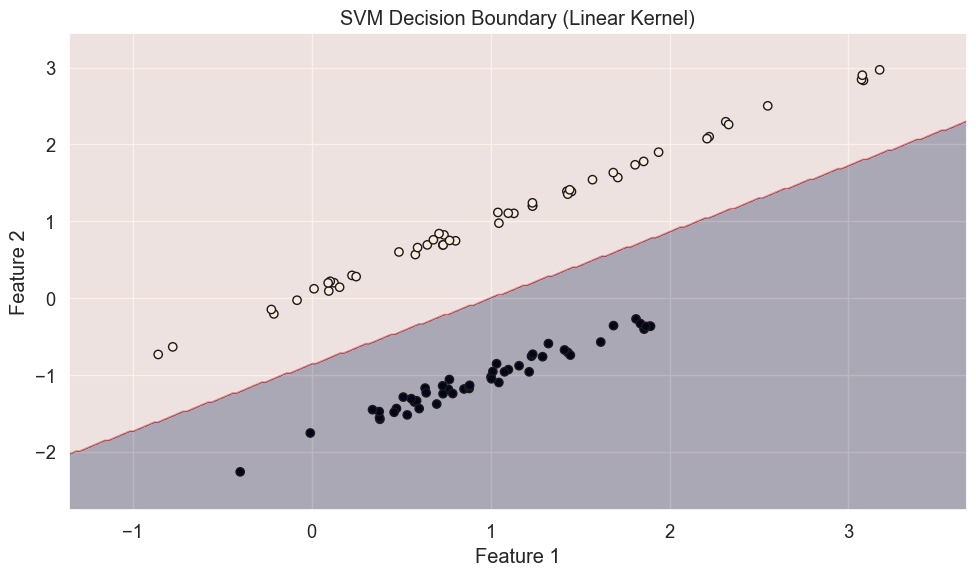

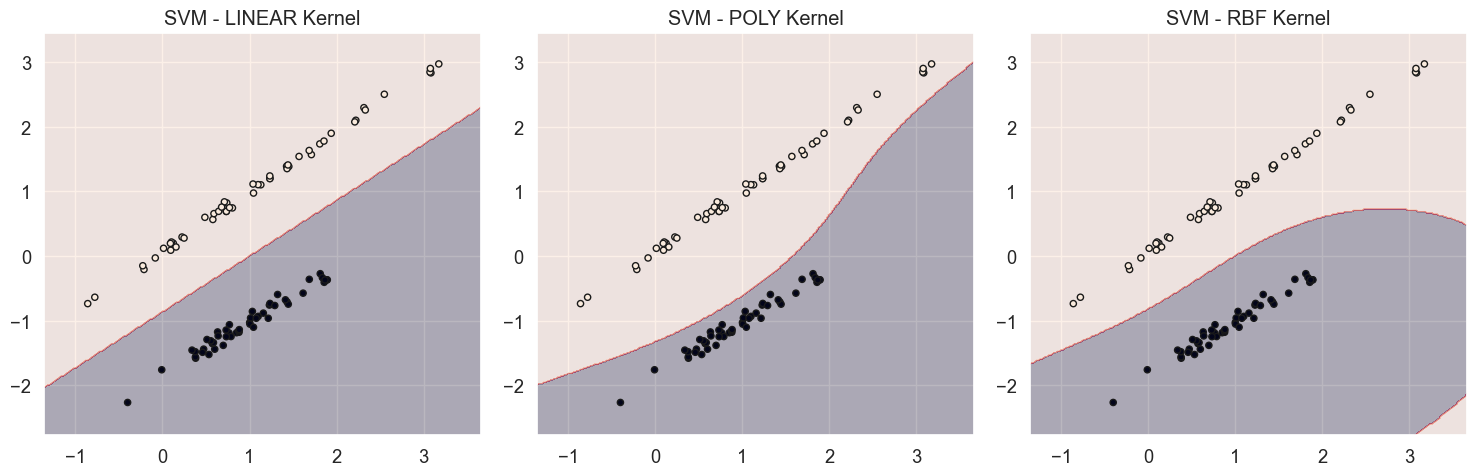

In [6]:
# SVM example
svm = SVC(kernel='linear', C=1.0, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(f"Linear SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

# Visualize the decision boundary
plot_decision_boundary(X, y, svm, "SVM Decision Boundary (Linear Kernel)")

# Compare different kernels
plt.figure(figsize=(15, 5))
kernels = ['linear', 'poly', 'rbf']

for i, kernel in enumerate(kernels):
    plt.subplot(1, 3, i+1)
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train, y_train)
    
    # Create mesh grid for decision boundary
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title(f"SVM - {kernel.upper()} Kernel")
    
plt.tight_layout()
plt.show()

## Preparing Data for Classification

Proper data preparation is crucial for building effective classification models. Let's discuss the key steps:

1. Handling missing values
2. Encoding categorical features
3. Feature scaling
4. Splitting data into training and testing sets

In [7]:
# Let's use the Breast Cancer dataset from sklearn
from sklearn.datasets import load_breast_cancer

# Load dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names
target_names = cancer.target_names

# Create a DataFrame for better visualization
cancer_df = pd.DataFrame(X, columns=feature_names)
cancer_df['target'] = y
cancer_df['diagnosis'] = cancer_df['target'].apply(lambda x: target_names[x])

# Display basic information
print(f"Dataset shape: {cancer_df.shape}")
print(f"Feature names: {feature_names[:5]}... (and {len(feature_names)-5} more)")
print(f"Target classes: {target_names}")
print(f"Class distribution: \n{cancer_df['diagnosis'].value_counts()}")

# Display the first few rows
cancer_df.head()

Dataset shape: (569, 32)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']... (and 25 more)
Target classes: ['malignant' 'benign']
Class distribution: 
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [8]:
# Check for missing values
print("Missing values per column:")
print(cancer_df.isnull().sum())

# Descriptive statistics
cancer_df.describe()

Missing values per column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
diagnosis                  0
dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Data Preparation Steps

In [9]:
# 1. Feature selection (simplified - using all features for this example)
X = cancer_df.drop(['target', 'diagnosis'], axis=1)
y = cancer_df['target']

# 2. Feature scaling - standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

print(f"Training set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set shape: X_test {X_test.shape}, y_test {y_test.shape}")

Training set shape: X_train (426, 30), y_train (426,)
Testing set shape: X_test (143, 30), y_test (143,)


## Binary Classification Example

Let's implement a complete binary classification workflow using the breast cancer dataset.

### Step 1: Data Exploration

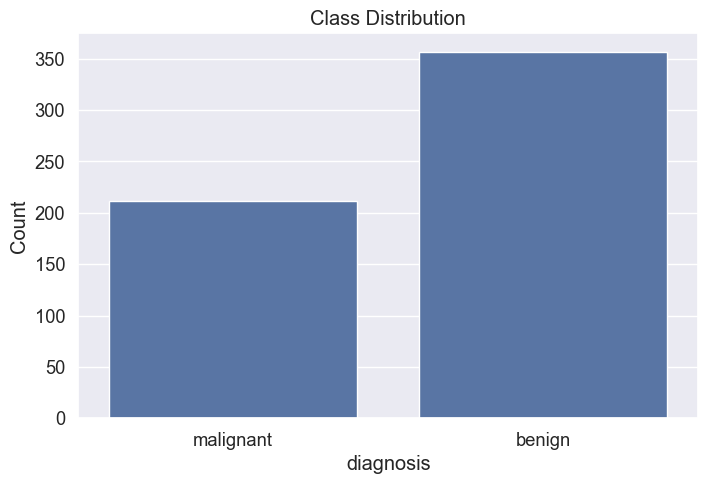

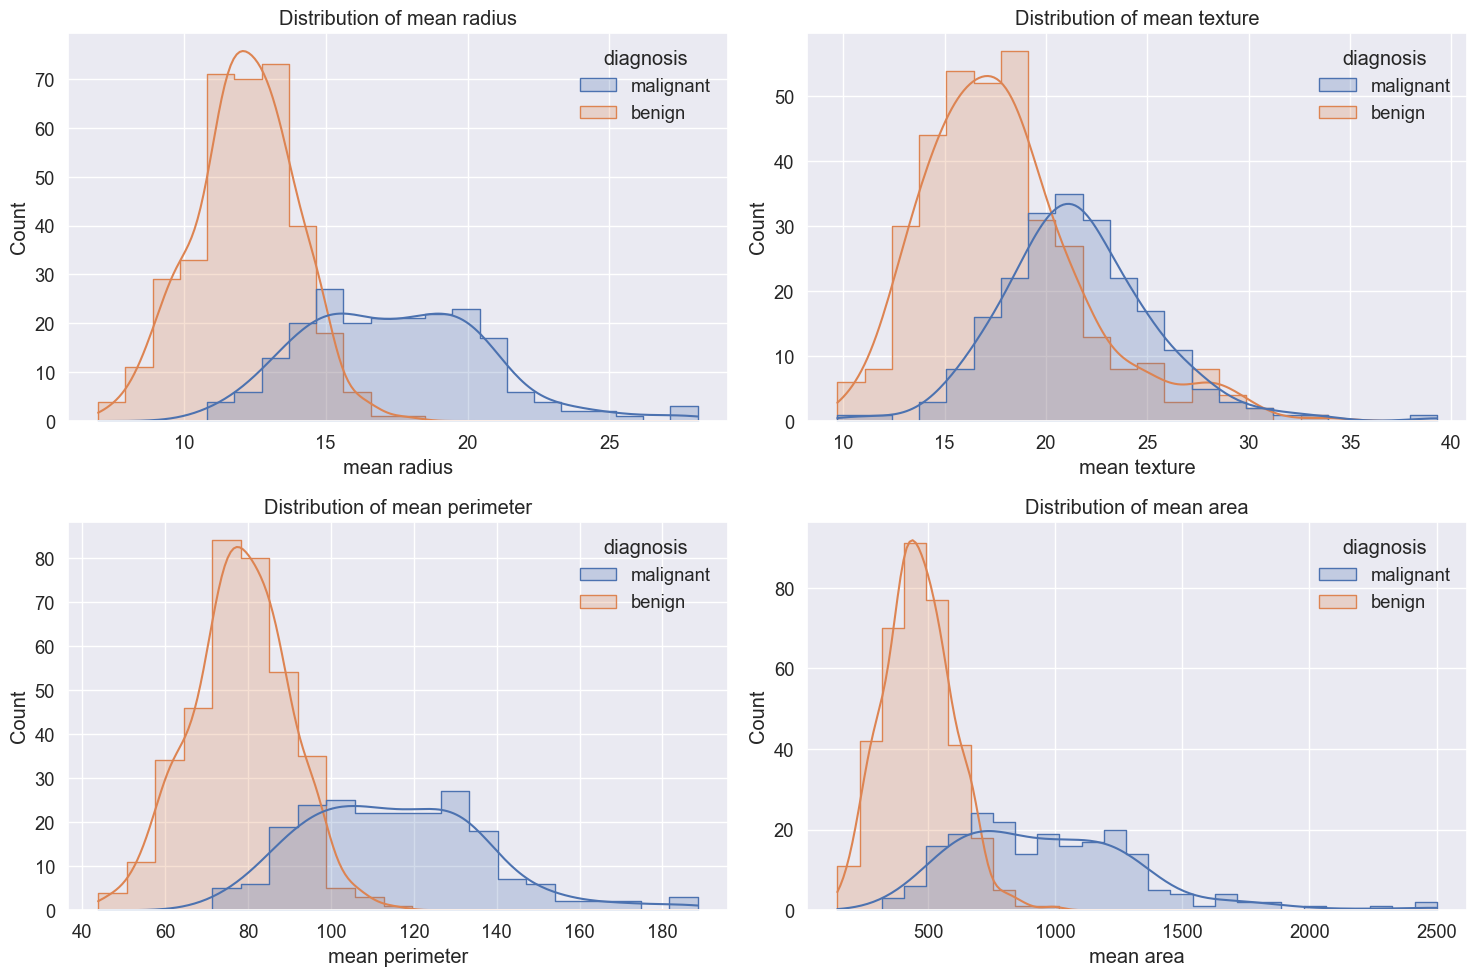

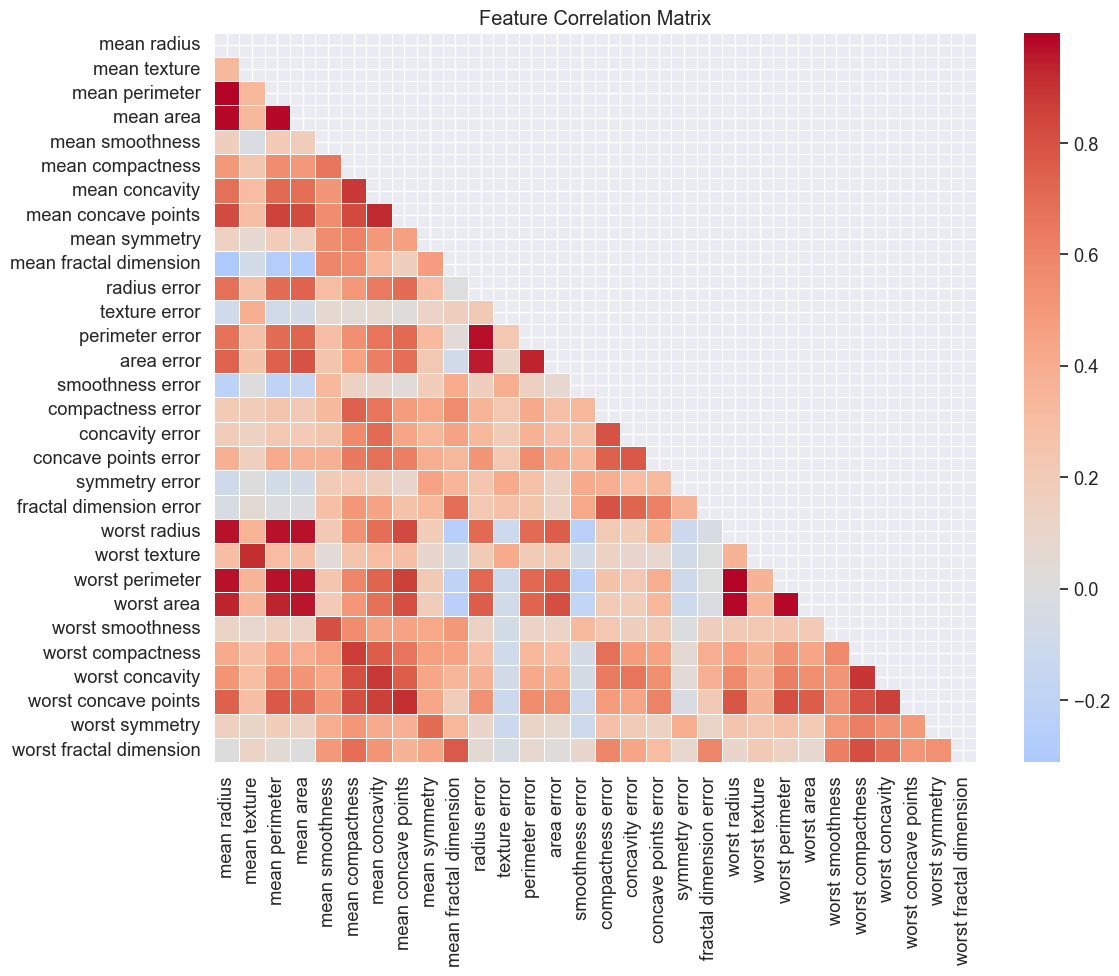

In [10]:
# Explore class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='diagnosis', data=cancer_df)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

# Visualize feature distributions by class
plt.figure(figsize=(15, 10))
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i+1)
    sns.histplot(data=cancer_df, x=feature, hue='diagnosis', kde=True, element="step")
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Correlation matrix of features
plt.figure(figsize=(12, 10))
correlation_matrix = cancer_df.iloc[:, :-2].corr()
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=False, mask=mask, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### Step 2: Train and Evaluate Multiple Models

In [11]:
# # Create a dictionary of models to evaluate
# models = {
#     'Logistic Regression': LogisticRegression(random_state=42),
#     'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3),
#     'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
#     'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
#     'Support Vector Machine': SVC(probability=True, random_state=42),
#     'Naive Bayes': GaussianNB()
# }

# # Train and evaluate each model
# results = {}
# for name, model in models.items():
#     # Train the model
#     model.fit(X_train, y_train)
    
#     # Make predictions
#     y_pred = model.predict(X_test)
    
#     # Calculate metrics
#     acc = accuracy_score(y_test, y_pred)
#     prec = precision_score(y_test, y_pred)
#     rec = recall_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred)
    
#     # Store results
#     results[name] = {
#         'accuracy': acc,
#         'precision': prec,
#         'recall': rec,
#         'f1_score': f1,
#         'model': model
#     }
    
#     print(f"\n{name} Results:")
#     print(f"Accuracy: {acc:.4f}")
#     print(f"Precision: {prec:.4f}")
#     print(f"Recall: {rec:.4f}")
#     print(f"F1-Score: {f1:.4f}")
#     print("\nClassification Report:")
#     print(classification_report(y_test, y_pred, target_names=target_names))

```
UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Systém nemůže nalézt uvedený soubor
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
```

In [33]:
import os
import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")

# Optionally, specify number of physical cores to avoid the warning altogether
os.environ["LOKY_MAX_CPU_COUNT"] = "4"  # Update this to match your physical core count

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Create a dictionary of models to evaluate
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'model': model
    }

    print(f"\n{name} Results:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))


Logistic Regression Results:
Accuracy: 0.9790
Precision: 0.9886
Recall: 0.9775
F1-Score: 0.9831

Classification Report:
              precision    recall  f1-score   support

   malignant       0.96      0.98      0.97        54
      benign       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143


K-Nearest Neighbors Results:
Accuracy: 0.9580
Precision: 0.9663
Recall: 0.9663
F1-Score: 0.9663

Classification Report:
              precision    recall  f1-score   support

   malignant       0.94      0.94      0.94        54
      benign       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143


Decision Tree Results:
Accuracy: 0.9580
Precision: 0.9770
Recall: 0.9551
F1-Score: 0.9659

Classificati

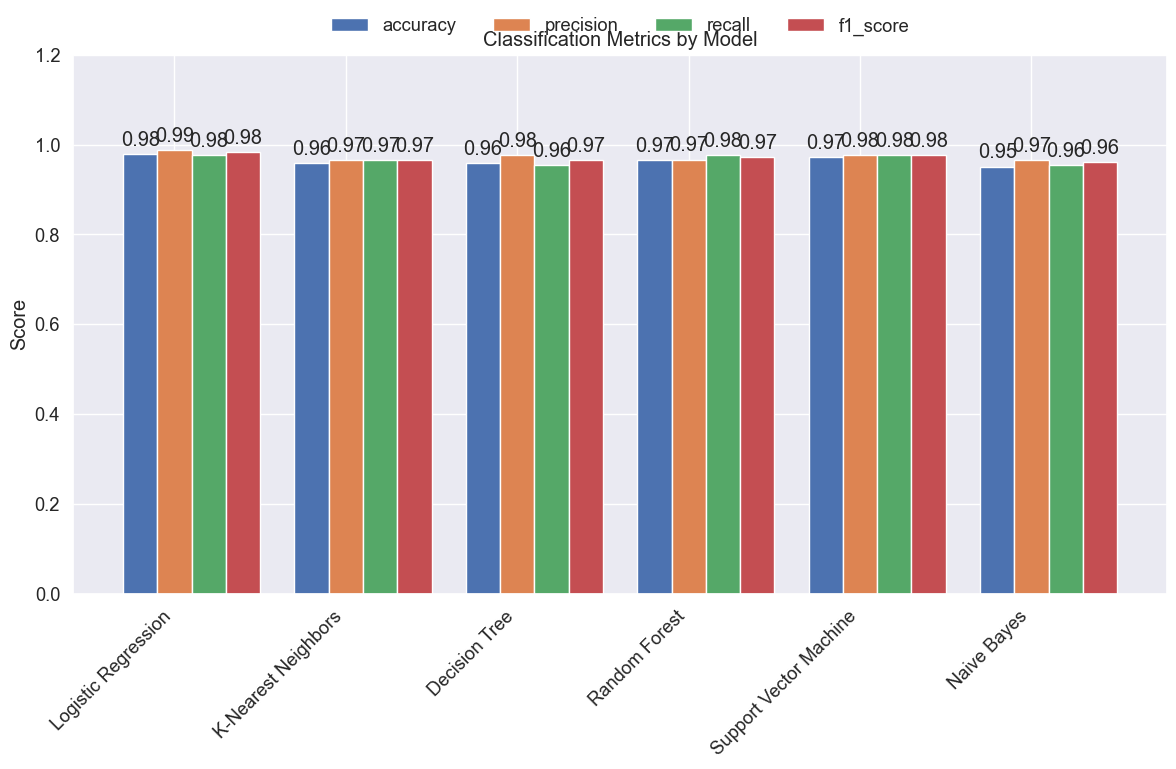

In [13]:
# Visualize model performance comparison
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
model_names = list(results.keys())
values = [
    [results[model][metric] for model in model_names]
    for metric in metrics
]

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(model_names))
width = 0.2
multiplier = 0

for metric, value in zip(metrics, values):
    offset = width * multiplier
    rects = ax.bar(x + offset, value, width, label=metric)
    ax.bar_label(rects, fmt='{:.2f}', padding=3)
    multiplier += 1

ax.set_ylabel('Score')
ax.set_title('Classification Metrics by Model')
ax.set_xticks(x + width, model_names, rotation=45, ha='right')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=4)
ax.set_ylim(0, 1.2)

plt.tight_layout()
plt.show()

### Step 3: Detailed Analysis of the Best Model

Based on our evaluation, let's select the best performing model for further analysis.

Best model: Logistic Regression


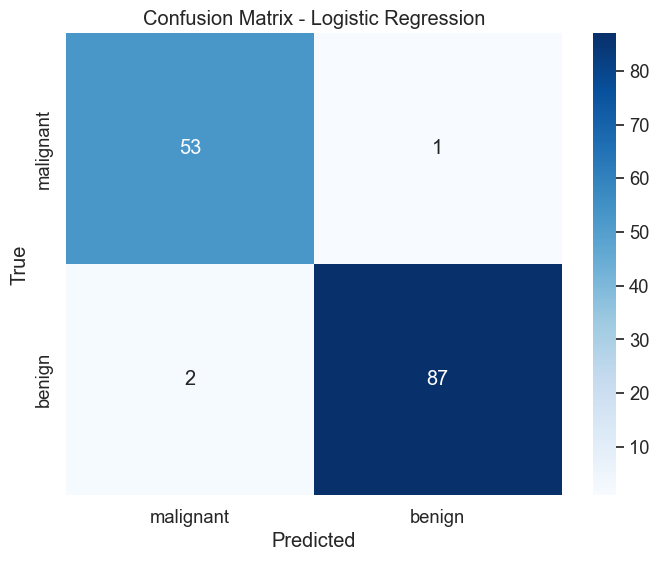

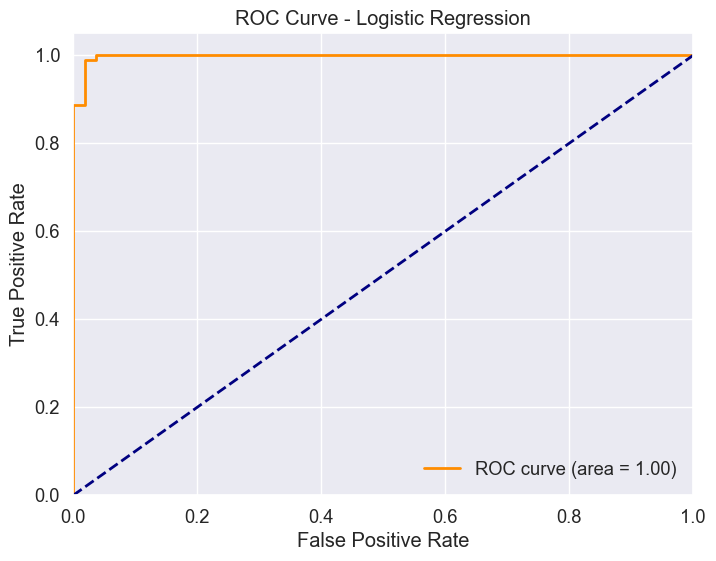

In [14]:
# Find the best model based on F1-score
best_model_name = max(results, key=lambda x: results[x]['f1_score'])
best_model = results[best_model_name]['model']

print(f"Best model: {best_model_name}")

# Confusion Matrix
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

# ROC curve and AUC
y_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc="lower right")
plt.show()

## Multi-class Classification Example

Let's implement a multi-class classification problem using the famous Iris dataset.

In [15]:
# Load Iris dataset
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target
iris_feature_names = iris.feature_names
iris_target_names = iris.target_names

# Create a pandas DataFrame
iris_df = pd.DataFrame(X_iris, columns=iris_feature_names)
iris_df['target'] = y_iris
iris_df['species'] = iris_df['target'].apply(lambda x: iris_target_names[x])

print(f"Dataset shape: {iris_df.shape}")
print(f"Features: {iris_feature_names}")
print(f"Target classes: {iris_target_names}")
print(f"Class distribution: \n{iris_df['species'].value_counts()}")

# Display first few rows
iris_df.head()

Dataset shape: (150, 6)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']
Class distribution: 
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


<Figure size 1200x800 with 0 Axes>

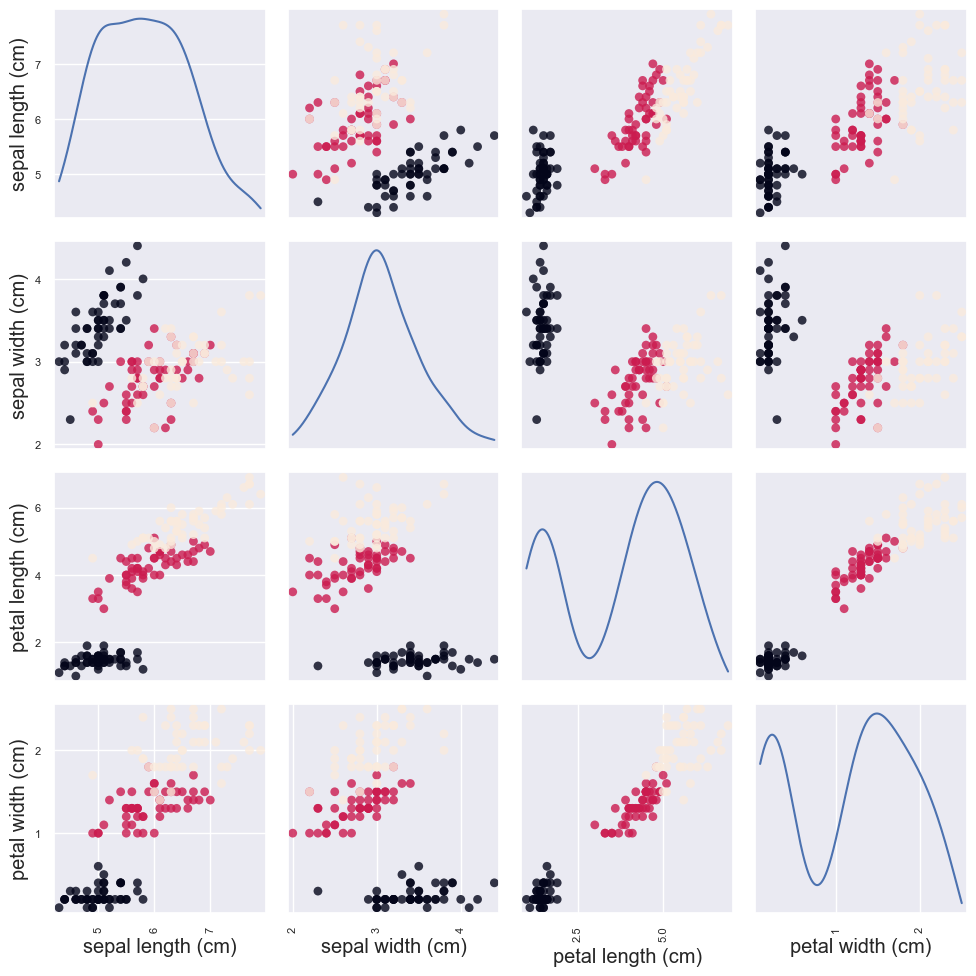

<Figure size 1200x800 with 0 Axes>

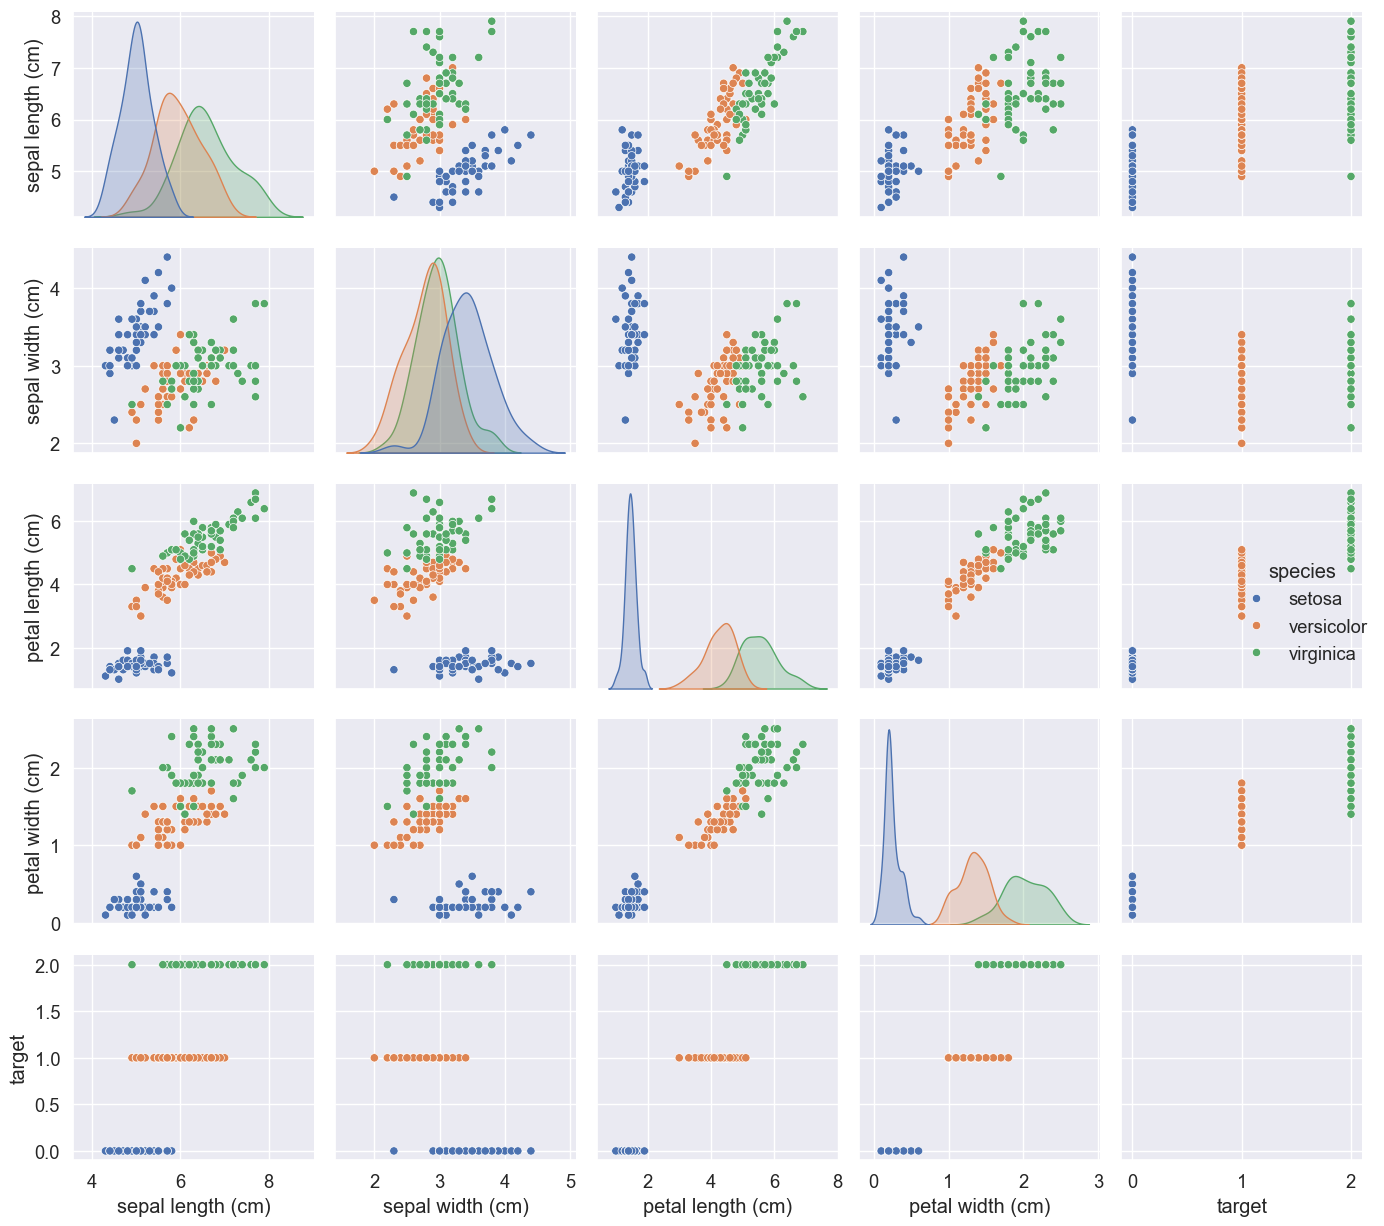

In [16]:
# Exploratory Data Analysis
plt.figure(figsize=(12, 8))

# Scatter matrix
pd.plotting.scatter_matrix(iris_df.iloc[:, :4], 
                         figsize=(10, 10),
                         diagonal='kde',
                         c=iris_df['target'],
                         marker='o',
                         s=40,
                         alpha=0.8)
plt.tight_layout()
plt.show()

# Pairplot using seaborn
plt.figure(figsize=(12, 8))
sns.pairplot(iris_df, hue="species", height=2.5)
plt.tight_layout()
plt.show()

In [17]:
# # Prepare data for modeling
# X_iris_scaled = StandardScaler().fit_transform(X_iris)
# X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
#     X_iris_scaled, y_iris, test_size=0.25, random_state=42
# )

# # Train and evaluate multiple models for multi-class classification
# models_iris = {
#     'Logistic Regression': LogisticRegression(random_state=42, multi_class='multinomial', solver='lbfgs'),
#     'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
#     'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
#     'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
#     'Support Vector Machine': SVC(probability=True, random_state=42),
#     'Naive Bayes': GaussianNB()
# }

# # Train and evaluate each model
# results_iris = {}
# for name, model in models_iris.items():
#     model.fit(X_train_iris, y_train_iris)
#     y_pred = model.predict(X_test_iris)
    
#     acc = accuracy_score(y_test_iris, y_pred)
#     results_iris[name] = {
#         'accuracy': acc,
#         'model': model
#     }
    
#     print(f"\n{name} Results:")
#     print(f"Accuracy: {acc:.4f}")
#     print("\nClassification Report:")
#     print(classification_report(y_test_iris, y_pred, target_names=iris_target_names))

```
FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
```

In [18]:
# Prepare data for modeling
X_iris_scaled = StandardScaler().fit_transform(X_iris)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris_scaled, y_iris, test_size=0.25, random_state=42
)

# Train and evaluate multiple models for multi-class classification
models_iris = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='lbfgs'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

# Train and evaluate each model
results_iris = {}
for name, model in models_iris.items():
    model.fit(X_train_iris, y_train_iris)
    y_pred = model.predict(X_test_iris)
    
    acc = accuracy_score(y_test_iris, y_pred)
    results_iris[name] = {
        'accuracy': acc,
        'model': model
    }
    
    print(f"\n{name} Results:")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_iris, y_pred, target_names=iris_target_names))


Logistic Regression Results:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38


K-Nearest Neighbors Results:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38


Decision Tree Results:
Accuracy: 1.0000

Classification Report:
              precision    reca

Best model for Iris classification: Logistic Regression
Explained variance ratio: [0.72962445 0.22850762]


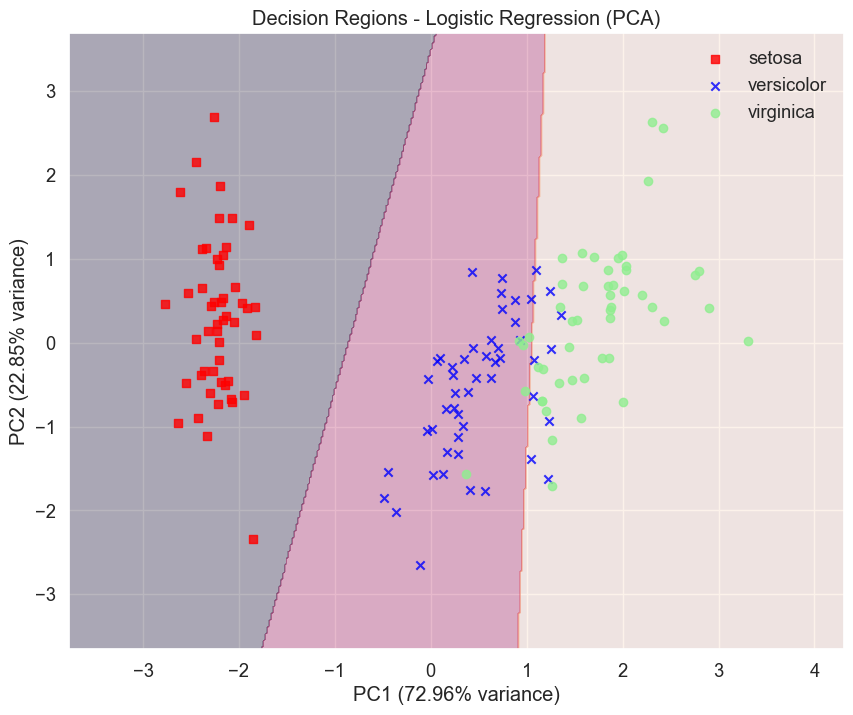

In [19]:
# Visualize the best model's predictions in feature space
best_model_name_iris = max(results_iris, key=lambda x: results_iris[x]['accuracy'])
best_model_iris = results_iris[best_model_name_iris]['model']

print(f"Best model for Iris classification: {best_model_name_iris}")

# Create a mesh to plot decision boundaries
def plot_decision_regions(X, y, classifier, resolution=0.02):
    # Setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    
    # Plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    
    plt.contourf(xx1, xx2, Z, alpha=0.3)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    # Plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                   alpha=0.8, c=colors[idx],
                   marker=markers[idx], label=iris_target_names[cl])

# We'll use PCA to reduce the data to 2D for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Train the best model on the PCA-transformed data
best_model_pca = models_iris[best_model_name_iris].__class__(**best_model_iris.get_params())
best_model_pca.fit(pca.transform(X_train_iris), y_train_iris)

# Plot the decision regions
plt.figure(figsize=(10, 8))
plot_decision_regions(X_iris_pca, y_iris, classifier=best_model_pca)
plt.title(f'Decision Regions - {best_model_name_iris} (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend()
plt.show()

## Model Evaluation Metrics

Choosing the right evaluation metrics is crucial for assessing classification performance. Different metrics are suitable for different scenarios, especially when dealing with imbalanced datasets.

Training set class distribution:
Class 0: 632 samples (90.29%)
Class 1: 68 samples (9.71%)


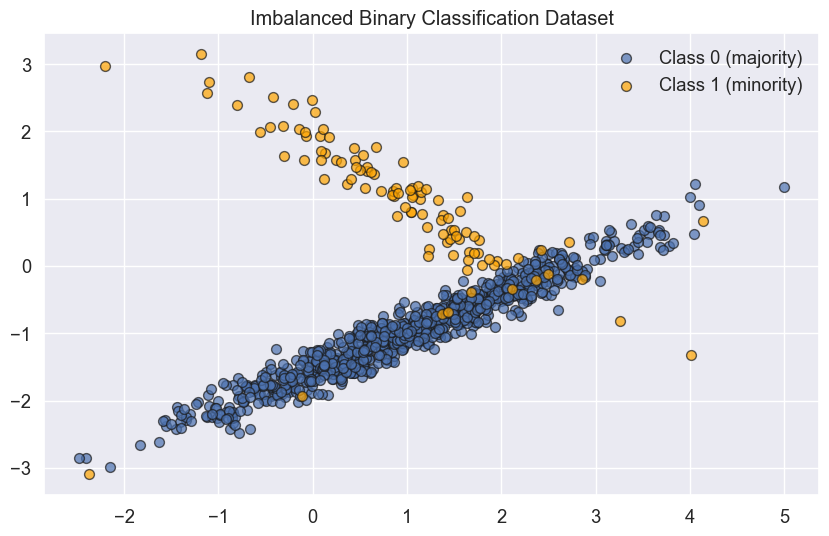

In [20]:
# Let's create a custom dataset to illustrate evaluation metrics
from sklearn.datasets import make_classification

# Create an imbalanced binary classification dataset
X_imbal, y_imbal = make_classification(
    n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, weights=[0.9, 0.1], random_state=42
)

# Split the data
X_train_imbal, X_test_imbal, y_train_imbal, y_test_imbal = train_test_split(
    X_imbal, y_imbal, test_size=0.3, random_state=42
)

# Check class distribution
unique, counts = np.unique(y_train_imbal, return_counts=True)
print("Training set class distribution:")
for i, (cls, count) in enumerate(zip(unique, counts)):
    print(f"Class {cls}: {count} samples ({count/len(y_train_imbal):.2%})")

# Visualize the imbalanced dataset
plt.figure(figsize=(10, 6))
plt.scatter(X_imbal[y_imbal == 0, 0], X_imbal[y_imbal == 0, 1], alpha=0.7, 
            s=50, label="Class 0 (majority)", edgecolors='k')
plt.scatter(X_imbal[y_imbal == 1, 0], X_imbal[y_imbal == 1, 1], alpha=0.7, 
            s=50, label="Class 1 (minority)", edgecolors='k', c='orange')
plt.title("Imbalanced Binary Classification Dataset")
plt.legend()
plt.show()

True Negatives: 263, False Positives: 0, False Negatives: 9, True Positives: 28


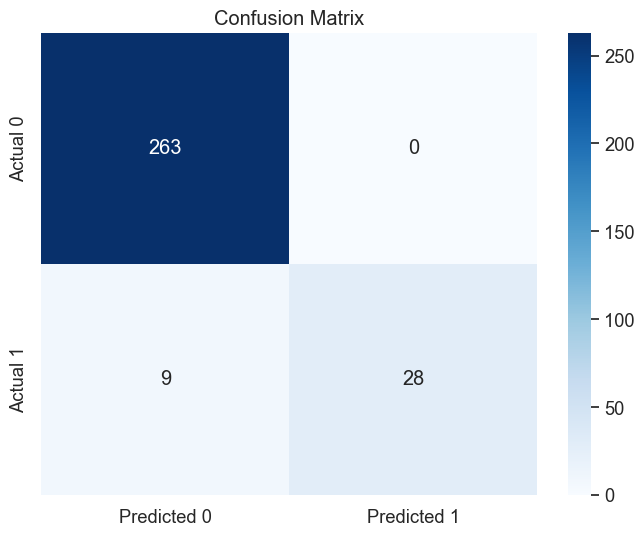

In [21]:
# Train a simple logistic regression model
clf_imbal = LogisticRegression(random_state=42)
clf_imbal.fit(X_train_imbal, y_train_imbal)

# Make predictions
y_pred_imbal = clf_imbal.predict(X_test_imbal)
y_prob_imbal = clf_imbal.predict_proba(X_test_imbal)[:, 1]

# 1. Confusion Matrix
cm_imbal = confusion_matrix(y_test_imbal, y_pred_imbal)
tn, fp, fn, tp = cm_imbal.ravel()
print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_imbal, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'], 
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.show()

In [22]:
# 2. Basic Metrics
accuracy = accuracy_score(y_test_imbal, y_pred_imbal)
precision = precision_score(y_test_imbal, y_pred_imbal)
recall = recall_score(y_test_imbal, y_pred_imbal)
f1 = f1_score(y_test_imbal, y_pred_imbal)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_imbal, y_pred_imbal))

# Calculating metrics manually to understand them better
print("\nManual calculation of metrics:")
print(f"Accuracy = (TP + TN) / (TP + TN + FP + FN) = ({tp} + {tn}) / ({tp} + {tn} + {fp} + {fn}) = {(tp + tn) / (tp + tn + fp + fn):.4f}")
print(f"Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f}")
print(f"Recall = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.4f}")
print(f"F1 Score = 2 * (Precision * Recall) / (Precision + Recall) = {2 * (precision * recall) / (precision + recall):.4f}")

Accuracy: 0.9700
Precision: 1.0000
Recall: 0.7568
F1-Score: 0.8615

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       263
           1       1.00      0.76      0.86        37

    accuracy                           0.97       300
   macro avg       0.98      0.88      0.92       300
weighted avg       0.97      0.97      0.97       300


Manual calculation of metrics:
Accuracy = (TP + TN) / (TP + TN + FP + FN) = (28 + 263) / (28 + 263 + 0 + 9) = 0.9700
Precision = TP / (TP + FP) = 28 / (28 + 0) = 1.0000
Recall = TP / (TP + FN) = 28 / (28 + 9) = 0.7568
F1 Score = 2 * (Precision * Recall) / (Precision + Recall) = 0.8615


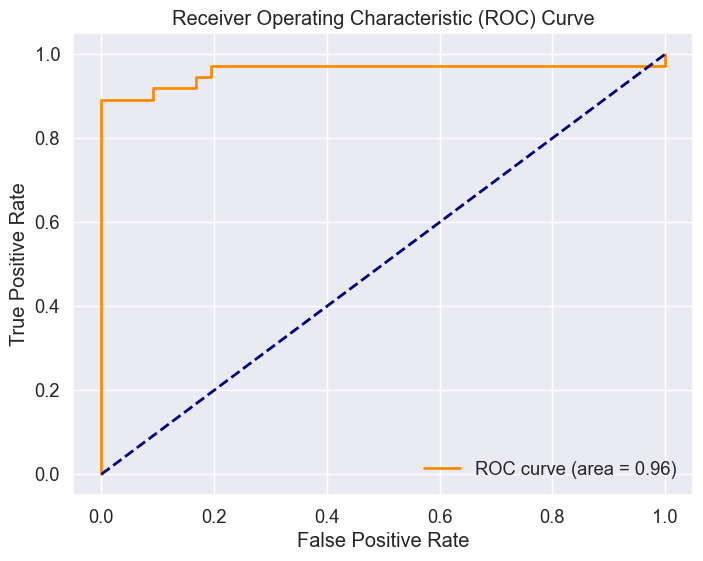

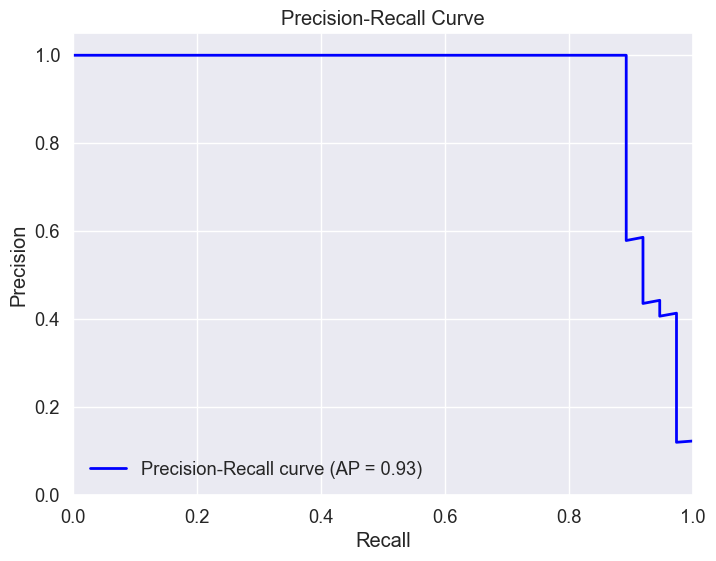

In [23]:
# 3. ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_imbal, y_prob_imbal)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# 4. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_values, recall_values, _ = precision_recall_curve(y_test_imbal, y_prob_imbal)
avg_precision = average_precision_score(y_test_imbal, y_prob_imbal)

plt.figure(figsize=(8, 6))
plt.plot(recall_values, precision_values, color='blue', lw=2, 
         label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

## Interpreting Classification Results

Understanding and interpreting classification results is essential for improving models and gaining insights from them. Let's explore some techniques:

1. Feature Importance
2. Decision Boundary Visualization
3. Individual Prediction Explanation

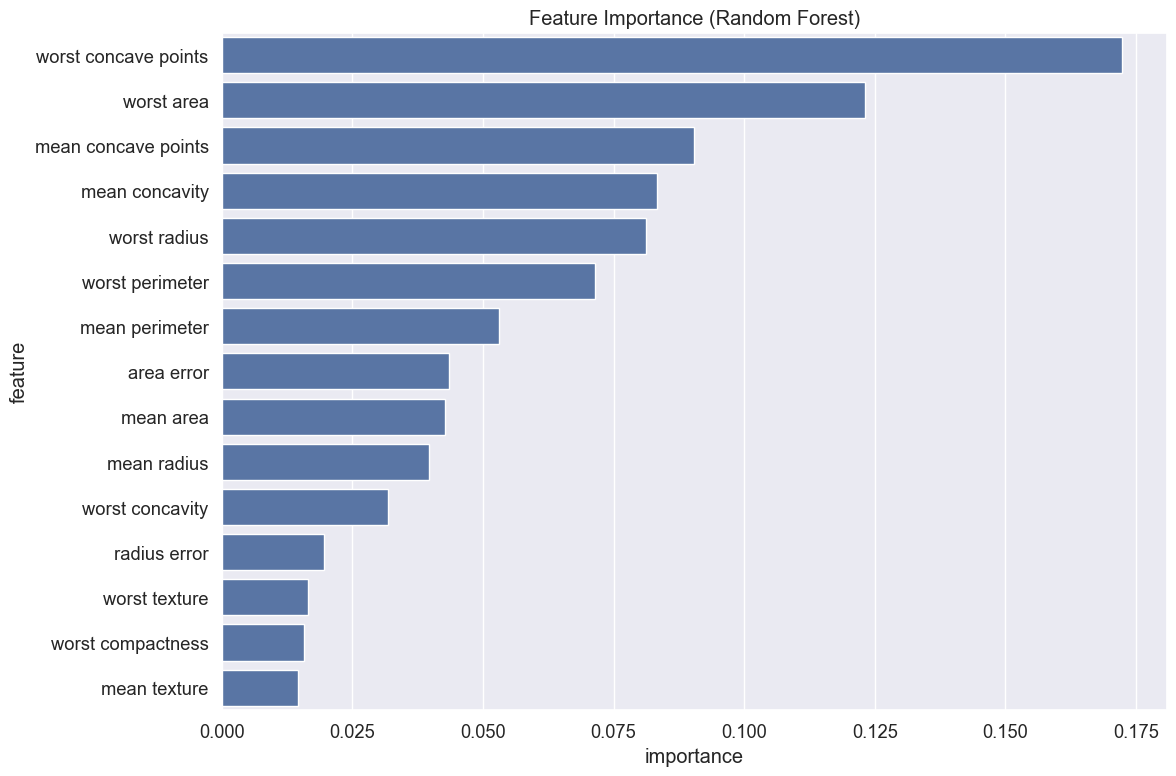

Top 5 most important features:
                 feature  importance
27  worst concave points    0.172295
23            worst area    0.123192
7    mean concave points    0.090299
6         mean concavity    0.083215
20          worst radius    0.081277


In [24]:
# Train a random forest classifier on the breast cancer dataset
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 1. Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feature_importance.head(5))

In [25]:
# # 2. Individual Prediction Explanation
# # Let's explain a specific prediction using model coefficients
# from sklearn.linear_model import LogisticRegression

# # Train a logistic regression model for interpretability
# log_reg_model = LogisticRegression(random_state=42)
# log_reg_model.fit(X_train, y_train)

# # Get a sample to explain
# sample_idx = 5  # Choose any sample from test set
# sample = X_test[sample_idx]
# true_label = y_test[sample_idx]
# pred_label = log_reg_model.predict([sample])[0]
# pred_prob = log_reg_model.predict_proba([sample])[0]

# print(f"True label: {target_names[true_label]}")
# print(f"Predicted label: {target_names[pred_label]}")
# print(f"Prediction probability: {pred_prob}")

# # Calculate feature contributions
# coef = log_reg_model.coef_[0]
# intercept = log_reg_model.intercept_[0]
# feature_contribution = coef * sample

# # Sort features by their contribution
# contributions = pd.DataFrame({
#     'Feature': feature_names,
#     'Value': sample,
#     'Coefficient': coef,
#     'Contribution': feature_contribution
# })
# contributions['Absolute_Contribution'] = abs(contributions['Contribution'])
# contributions = contributions.sort_values('Absolute_Contribution', ascending=False)

# # Plot top feature contributions
# plt.figure(figsize=(12, 8))
# top_n = 10
# sns.barplot(x='Contribution', y='Feature', data=contributions.head(top_n))
# plt.title(f'Top {top_n} Feature Contributions for Sample Prediction')
# plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
# plt.tight_layout()
# plt.show()

```
KeyError: 5

[ChatGPT]
means you're trying to access the value in y_test using an index label (5), but y_test is a pandas Series with non-continuous or shuffled index labels after a train_test_split.
To fix this, you should use positional indexing (iloc) instead of label-based indexing:
```

True label: malignant
Predicted label: malignant
Prediction probability: [1.00000000e+00 1.49490475e-10]


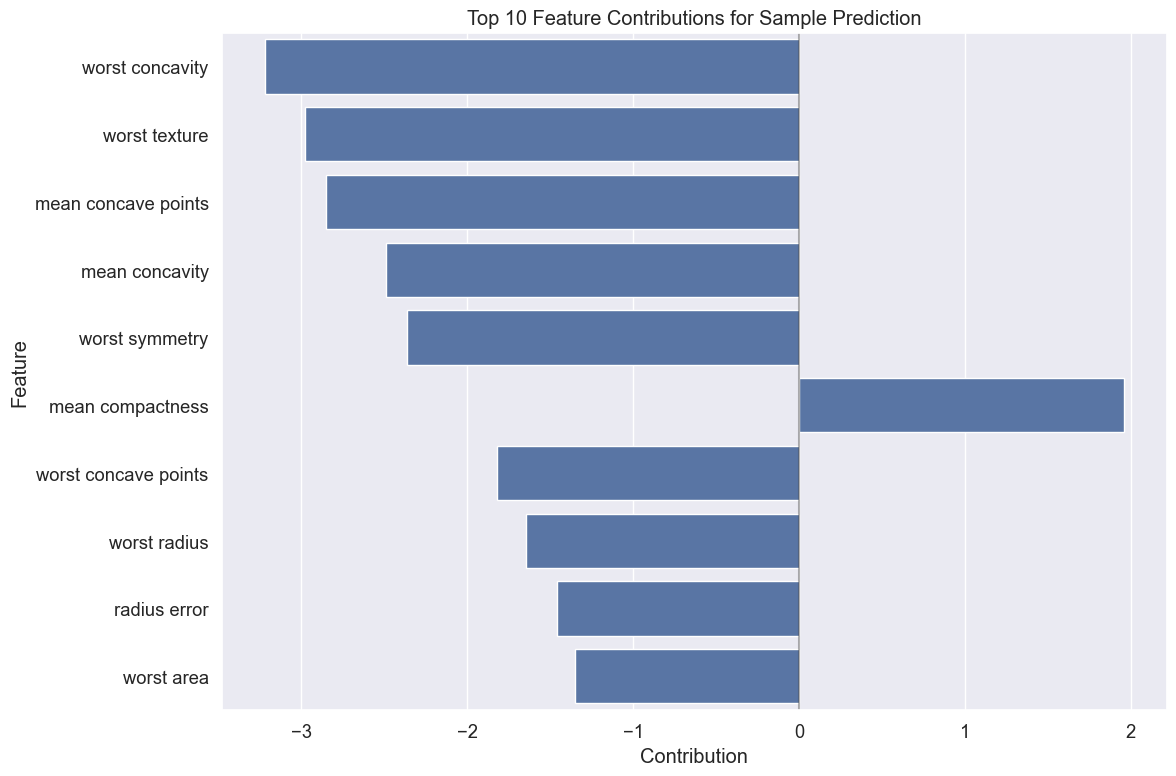

In [26]:
# Train a logistic regression model for interpretability
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)

# Get a sample to explain
sample_idx = 5  # Choose any sample from test set

# Handle both pandas and NumPy
sample = X_test[sample_idx] if isinstance(X_test, np.ndarray) else X_test.iloc[sample_idx]
true_label = y_test[sample_idx] if isinstance(y_test, np.ndarray) else y_test.iloc[sample_idx]
pred_label = log_reg_model.predict([sample])[0]
pred_prob = log_reg_model.predict_proba([sample])[0]

print(f"True label: {target_names[true_label]}")
print(f"Predicted label: {target_names[pred_label]}")
print(f"Prediction probability: {pred_prob}")

# Calculate feature contributions
if log_reg_model.coef_.shape[0] > 1:
    # Multiclass: use the predicted class coefficients
    coef = log_reg_model.coef_[pred_label]
    intercept = log_reg_model.intercept_[pred_label]
else:
    coef = log_reg_model.coef_[0]
    intercept = log_reg_model.intercept_[0]

sample_array = sample if isinstance(sample, np.ndarray) else sample.values
feature_contribution = coef * sample_array

# Create DataFrame of contributions
contributions = pd.DataFrame({
    'Feature': feature_names,
    'Value': sample_array,
    'Coefficient': coef,
    'Contribution': feature_contribution
})
contributions['Absolute_Contribution'] = contributions['Contribution'].abs()
contributions = contributions.sort_values('Absolute_Contribution', ascending=False)

# Plot top feature contributions
plt.figure(figsize=(12, 8))
top_n = 10
sns.barplot(x='Contribution', y='Feature', data=contributions.head(top_n))
plt.title(f'Top {top_n} Feature Contributions for Sample Prediction')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

## Handling Class Imbalance

Imbalanced datasets are common in real-world classification problems. Here are some techniques to handle class imbalance:

1. Resampling techniques
   - Random Oversampling (minority class)
   - Random Undersampling (majority class)
   - SMOTE (Synthetic Minority Over-sampling Technique)
2. Algorithm-level approaches
   - Class weights
   - Cost-sensitive learning
3. Evaluation metrics for imbalanced datasets

In [27]:
# Let's work with our imbalanced dataset from earlier
print("Original class distribution:")
print(pd.Series(y_train_imbal).value_counts())

# 1. Random Oversampling
from sklearn.utils import resample

# Separate majority and minority classes in training data
X_train_majority = X_train_imbal[y_train_imbal == 0]
y_train_majority = y_train_imbal[y_train_imbal == 0]
X_train_minority = X_train_imbal[y_train_imbal == 1]
y_train_minority = y_train_imbal[y_train_imbal == 1]

# Oversample minority class
X_minority_upsampled, y_minority_upsampled = resample(
    X_train_minority, y_train_minority,
    replace=True,  # sample with replacement
    n_samples=len(X_train_majority),  # match majority class
    random_state=42  # reproducible results
)

# Combine majority class with upsampled minority class
X_train_oversampled = np.vstack([X_train_majority, X_minority_upsampled])
y_train_oversampled = np.hstack([y_train_majority, y_minority_upsampled])

print("\nAfter oversampling:")
print(pd.Series(y_train_oversampled).value_counts())

Original class distribution:
0    632
1     68
Name: count, dtype: int64

After oversampling:
0    632
1    632
Name: count, dtype: int64


In [28]:
# 2. Random Undersampling
X_majority_downsampled, y_majority_downsampled = resample(
    X_train_majority, y_train_majority,
    replace=False,  # sample without replacement
    n_samples=len(X_train_minority),  # match minority class
    random_state=42  # reproducible results
)

# Combine downsampled majority class with minority class
X_train_undersampled = np.vstack([X_majority_downsampled, X_train_minority])
y_train_undersampled = np.hstack([y_majority_downsampled, y_train_minority])

print("\nAfter undersampling:")
print(pd.Series(y_train_undersampled).value_counts())


After undersampling:
0    68
1    68
Name: count, dtype: int64



After SMOTE:
0    632
1    632
Name: count, dtype: int64


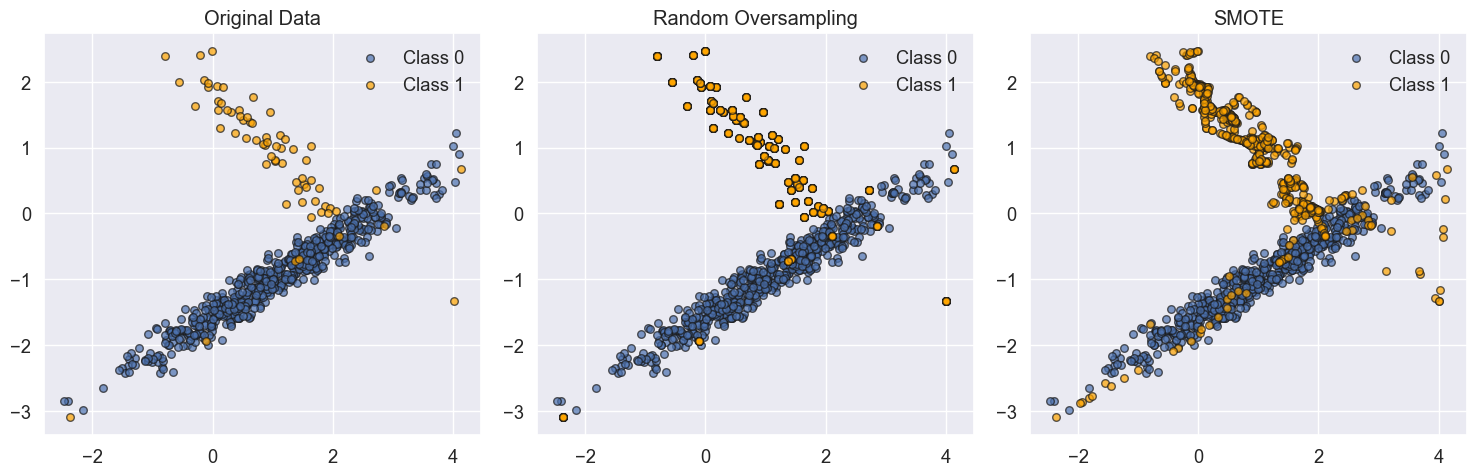

In [29]:
# 3. SMOTE: Synthetic Minority Over-sampling Technique
# pip install imbalanced-learn (if not already installed)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imbal, y_train_imbal)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Visualize the effect of SMOTE
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_train_imbal[y_train_imbal == 0, 0], X_train_imbal[y_train_imbal == 0, 1], 
            alpha=0.7, s=30, label="Class 0", edgecolors='k')
plt.scatter(X_train_imbal[y_train_imbal == 1, 0], X_train_imbal[y_train_imbal == 1, 1], 
            alpha=0.7, s=30, label="Class 1", edgecolors='k', c='orange')
plt.title("Original Data")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X_train_oversampled[y_train_oversampled == 0, 0], X_train_oversampled[y_train_oversampled == 0, 1], 
            alpha=0.7, s=30, label="Class 0", edgecolors='k')
plt.scatter(X_train_oversampled[y_train_oversampled == 1, 0], X_train_oversampled[y_train_oversampled == 1, 1], 
            alpha=0.7, s=30, label="Class 1", edgecolors='k', c='orange')
plt.title("Random Oversampling")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X_train_smote[y_train_smote == 0, 0], X_train_smote[y_train_smote == 0, 1], 
            alpha=0.7, s=30, label="Class 0", edgecolors='k')
plt.scatter(X_train_smote[y_train_smote == 1, 0], X_train_smote[y_train_smote == 1, 1], 
            alpha=0.7, s=30, label="Class 1", edgecolors='k', c='orange')
plt.title("SMOTE")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
# # 4. Compare performance of models trained with different sampling approaches
# # Create a function to train and evaluate a model
# def train_and_evaluate(X_train, y_train, X_test, y_test, model_name="Logistic Regression"):
#     model = LogisticRegression(random_state=42)
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     y_prob = model.predict_proba(X_test)[:, 1]
    
#     results = {
#         'accuracy': accuracy_score(y_test, y_pred),
#         'precision': precision_score(y_test, y_pred),
#         'recall': recall_score(y_test, y_pred),
#         'f1': f1_score(y_test, y_pred),
#         'auc': roc_auc_score(y_test, y_prob)
#     }
#     return results

# # Compare different approaches
# approaches = {
#     'Original Imbalanced Data': (X_train_imbal, y_train_imbal),
#     'Random Oversampling': (X_train_oversampled, y_train_oversampled),
#     'Random Undersampling': (X_train_undersampled, y_train_undersampled),
#     'SMOTE': (X_train_smote, y_train_smote),
#     'Class Weights': (X_train_imbal, y_train_imbal)  # We'll use class_weight='balanced'
# }

# results_comparison = {}

# for name, (X, y) in approaches.items():
#     if name == 'Class Weights':
#         model = LogisticRegression(random_state=42, class_weight='balanced')
#         model.fit(X, y)
#         y_pred = model.predict(X_test_imbal)
#         y_prob = model.predict_proba(X_test_imbal)[:, 1]
        
#         results = {
#             'accuracy': accuracy_score(y_test_imbal, y_pred),
#             'precision': precision_score(y_test_imbal, y_pred),
#             'recall': recall_score(y_test_imbal, y_pred),
#             'f1': f1_score(y_test_imbal, y_pred),
#             'auc': roc_auc_score(y_test_imbal, y_prob)
#         }
#     else:
#         results = train_and_evaluate(X, y, X_test_imbal, y_test_imbal)
    
#     results_comparison[name] = results
    
#     print(f"\n{name}:")
#     for metric, value in results.items():
#         print(f"  {metric}: {value:.4f}")

```
NameError: name 'roc_auc_score' is not defined
```

In [31]:
from sklearn.metrics import roc_auc_score

# 4. Compare performance of models trained with different sampling approaches
# Create a function to train and evaluate a model
def train_and_evaluate(X_train, y_train, X_test, y_test, model_name="Logistic Regression"):
    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }
    return results

# Compare different approaches
approaches = {
    'Original Imbalanced Data': (X_train_imbal, y_train_imbal),
    'Random Oversampling': (X_train_oversampled, y_train_oversampled),
    'Random Undersampling': (X_train_undersampled, y_train_undersampled),
    'SMOTE': (X_train_smote, y_train_smote),
    'Class Weights': (X_train_imbal, y_train_imbal)  # We'll use class_weight='balanced'
}

results_comparison = {}

for name, (X, y) in approaches.items():
    if name == 'Class Weights':
        model = LogisticRegression(random_state=42, class_weight='balanced')
        model.fit(X, y)
        y_pred = model.predict(X_test_imbal)
        y_prob = model.predict_proba(X_test_imbal)[:, 1]

        results = {
            'accuracy': accuracy_score(y_test_imbal, y_pred),
            'precision': precision_score(y_test_imbal, y_pred),
            'recall': recall_score(y_test_imbal, y_pred),
            'f1': f1_score(y_test_imbal, y_pred),
            'auc': roc_auc_score(y_test_imbal, y_prob)
        }
    else:
        results = train_and_evaluate(X, y, X_test_imbal, y_test_imbal)

    results_comparison[name] = results

    print(f"\n{name}:")
    for metric, value in results.items():
        print(f"  {metric}: {value:.4f}")


Original Imbalanced Data:
  accuracy: 0.9700
  precision: 1.0000
  recall: 0.7568
  f1: 0.8615
  auc: 0.9607

Random Oversampling:
  accuracy: 0.9800
  precision: 0.9429
  recall: 0.8919
  f1: 0.9167
  auc: 0.9624

Random Undersampling:
  accuracy: 0.9600
  precision: 0.8049
  recall: 0.8919
  f1: 0.8462
  auc: 0.9655

SMOTE:
  accuracy: 0.9833
  precision: 0.9706
  recall: 0.8919
  f1: 0.9296
  auc: 0.9608

Class Weights:
  accuracy: 0.9800
  precision: 0.9429
  recall: 0.8919
  f1: 0.9167
  auc: 0.9618


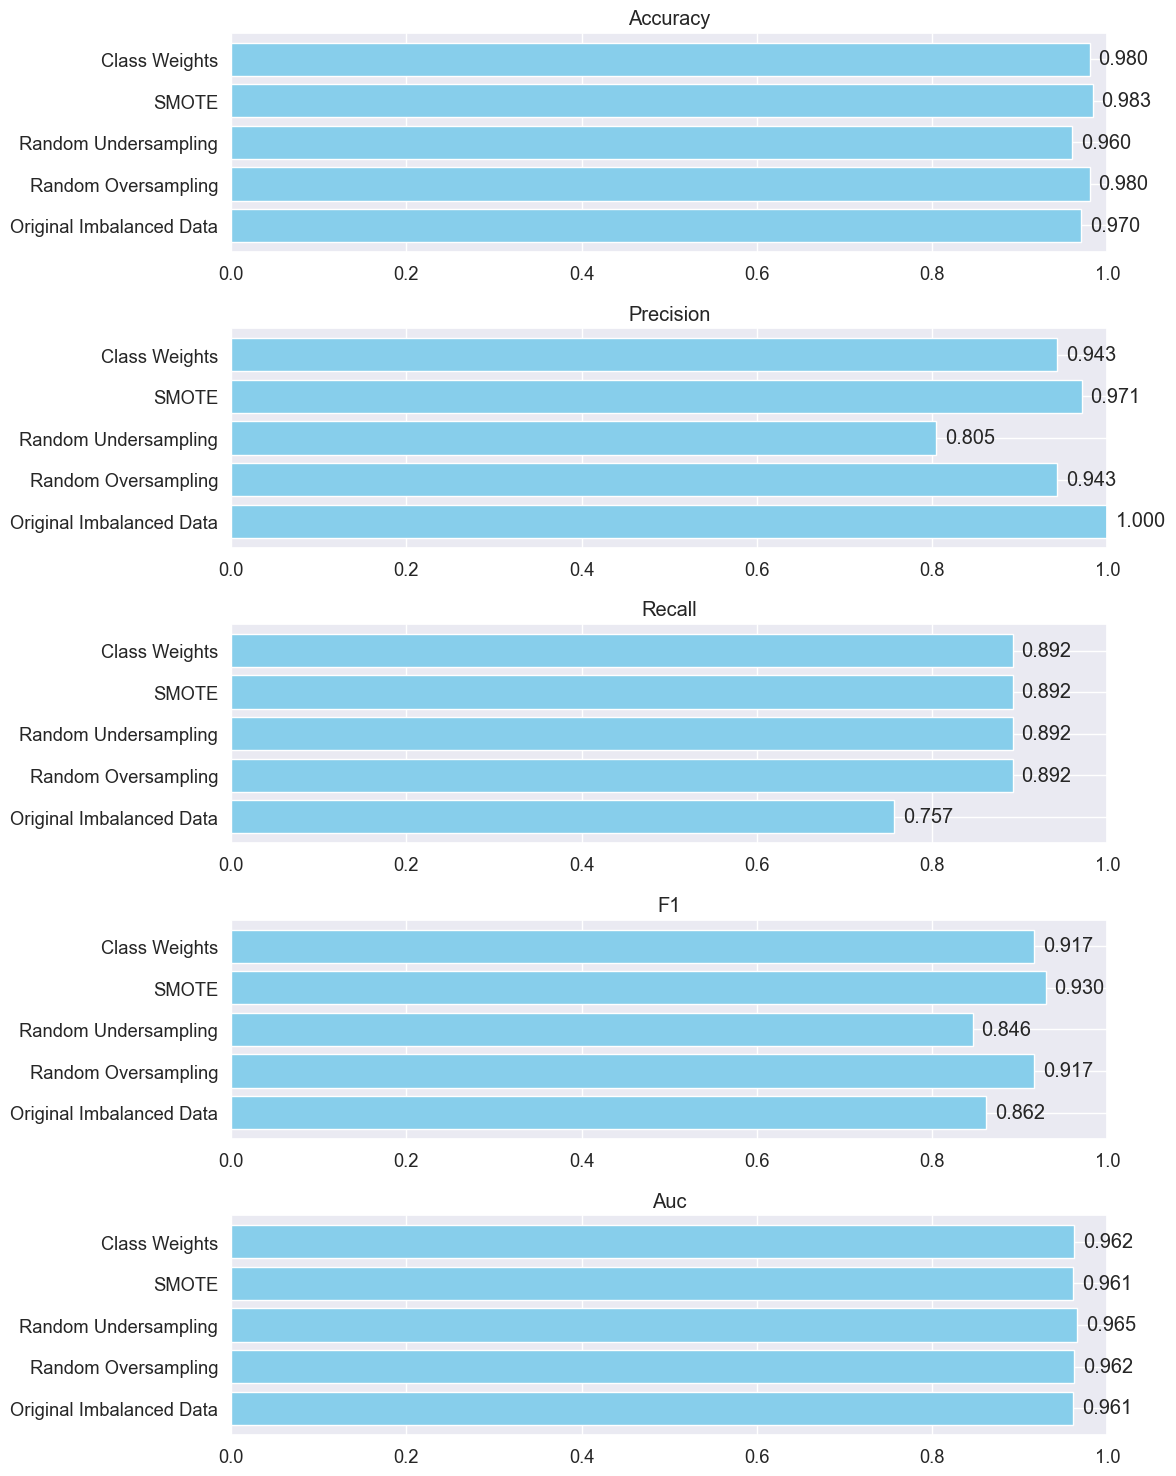

In [32]:
# Visualize the comparison
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
approaches_list = list(results_comparison.keys())

fig, axs = plt.subplots(len(metrics), 1, figsize=(12, 15))
for i, metric in enumerate(metrics):
    values = [results_comparison[approach][metric] for approach in approaches_list]
    axs[i].barh(approaches_list, values, color='skyblue')
    axs[i].set_title(f'{metric.capitalize()}')
    axs[i].set_xlim(0, 1)
    
    # Add values to the bars
    for j, value in enumerate(values):
        axs[i].text(value + 0.01, j, f'{value:.3f}', va='center')

plt.tight_layout()
plt.show()

## Summary

In this notebook, we've covered the fundamentals of classification in machine learning:

1. **Understanding Classification**: Learned about the basic concepts and types of classification problems.

2. **Classification Algorithms**: Explored common algorithms including Logistic Regression, Decision Trees, k-Nearest Neighbors, Naive Bayes, and Support Vector Machines.

3. **Data Preparation**: Covered essential steps for preparing data for classification tasks, including feature scaling and handling categorical variables.

4. **Binary Classification**: Implemented a complete binary classification workflow with the breast cancer dataset.

5. **Multi-class Classification**: Applied classification techniques to the multi-class Iris dataset.

6. **Evaluation Metrics**: Explored various metrics for assessing classification performance, including accuracy, precision, recall, F1-score, ROC curves, and AUC.

7. **Interpreting Results**: Learned techniques for understanding and interpreting classification results through feature importance and prediction explanations.

8. **Handling Class Imbalance**: Discovered methods for dealing with imbalanced datasets, including resampling techniques like SMOTE and algorithmic approaches like class weighting.

Classification is a fundamental machine learning task with numerous real-world applications. The techniques covered in this notebook provide a solid foundation for tackling a wide range of classification problems.